## Estimación preliminar del calor introducido por la pared en el lecho

Con el objetivo de estimar la potencia térmica introducida por la pared del reactor en ausencia de biomasa y sin flujo de N₂, se ha planteado un modelo simplificado basado en la evolución temporal de la temperatura medida en tres zonas del lecho.

### Geometría considerada

Se considera el tramo inferior del reactor, correspondiente al lecho, con las siguientes dimensiones:

- Longitud total del lecho: \(L = 0.75\ \mathrm{m}\)
- Radio interior: \(r_i = 0.04\ \mathrm{m}\)
- Radio exterior: \(r_o = 0.045\ \mathrm{m}\)

El lecho se discretiza en **3 zonas axiales equivalentes**, por lo que la longitud de cada zona es:

\[
\Delta x = \frac{L}{3}
\]

Cada una de las tres sondas de temperatura se asocia a la **temperatura media de una zona completa**.

### Hipótesis adoptadas

Para esta primera estimación se asumen las siguientes hipótesis:

1. **No existe flujo de N₂** durante el intervalo analizado.  
   Por tanto, no hay transporte convectivo de energía de entrada ni de salida.

2. **No hay biomasa en el interior del lecho**.  
   En consecuencia, no existen contribuciones energéticas debidas a:
   - calentamiento del sólido,
   - evaporación,
   - devolatilización,
   - reacción.

3. **Cada sonda representa la temperatura media de una zona axial completa**.  
   Es decir, la temperatura medida por cada sonda se interpreta como temperatura media representativa de una de las tres zonas del lecho.

4. **La temperatura medida en cada zona se asimila a la temperatura efectiva de la pared en dicha zona**.  
   Esta es una hipótesis simplificadora inicial, que permite estimar la energía acumulada en la pared a partir de la señal térmica medida.

5. **En esta primera aproximación solo se considera la capacidad térmica de la pared metálica**.  
   No se incluye todavía la contribución de:
   - gas interno,
   - accesorios internos,
   - ni pérdidas térmicas al ambiente.

6. **Las propiedades del material de la pared se consideran constantes** en el intervalo de temperatura analizado:
   - densidad de la pared: \(\rho_{wall}\)
   - calor específico de la pared: \(c_{p,wall}\)

7. **La conducción axial entre zonas se desprecia en esta primera estimación**.  
   Por tanto, la potencia calculada para cada zona se interpreta como la potencia neta necesaria para explicar la acumulación térmica observada en dicha zona.

### Volumen y masa de pared por zona

El volumen de pared asociado a una zona se calcula como:

\[
V_{wall,z} = \pi \left(r_o^2 - r_i^2\right)\Delta x
\]

La masa de pared correspondiente a cada zona es:

\[
m_{wall,z} = \rho_{wall}\,V_{wall,z}
\]

y su capacidad térmica:

\[
C_{wall,z} = m_{wall,z}\,c_{p,wall}
\]

### Potencia térmica introducida por la pared en cada zona

Bajo las hipótesis anteriores, la potencia térmica introducida por la pared en la zona \(i\) se estima a partir del término de acumulación energética:

\[
\dot{Q}_{wall,i}(t) = m_{wall,z}\,c_{p,wall}\,\frac{dT_i}{dt}
\]

o equivalentemente:

\[
\dot{Q}_{wall,i}(t) = C_{wall,z}\,\frac{dT_i}{dt}
\]

donde:

- \(T_i(t)\) es la temperatura media medida en la zona \(i\),
- \(\dfrac{dT_i}{dt}\) es su derivada temporal,
- \(\dot{Q}_{wall,i}(t)\) representa la potencia térmica absorbida por esa zona.

### Potencia total en el tramo instrumentado

La potencia total estimada en las tres zonas consideradas se obtiene como:

\[
\dot{Q}_{wall,total}(t)=\sum_{i=1}^{3}\dot{Q}_{wall,i}(t)
\]

es decir,

\[
\dot{Q}_{wall,total}(t)=\dot{Q}_{wall,1}(t)+\dot{Q}_{wall,2}(t)+\dot{Q}_{wall,3}(t)
\]

### Interpretación del resultado

La magnitud \(\dot{Q}_{wall,total}(t)\) obtenida mediante este procedimiento constituye una **estimación preliminar del calor introducido por la pared al interior del lecho** en condiciones simplificadas.

Aunque esta estimación no incluye todavía:
- pérdidas al ambiente,
- acumulación energética del gas,
- ni conducción axial entre zonas,

sí proporciona una primera referencia útil para evaluar:

- el orden de magnitud del calor cedido por la pared,
- su evolución temporal,
- y si dicho aporte puede aproximarse razonablemente como constante.

### Utilidad para la definición futura de \(Q_{wall}\)

Este cálculo preliminar se utilizará como base para definir el término \(Q_{wall}\) en el modelo térmico futuro del reactor.

En particular, el análisis de \(\dot{Q}_{wall,total}(t)\) permitirá decidir si el aporte térmico de pared puede representarse como:

- una **potencia constante**,
- una **potencia dependiente del tiempo**,
- o una **ley más física basada en transferencia de calor**, por ejemplo del tipo:

\[
Q_{wall} = U A \left(T_{wall} - T_{medio}\right)
\]

Por tanto, este procedimiento no debe interpretarse como el modelo térmico final, sino como una **herramienta de identificación preliminar** para acotar y justificar la forma que adoptará el término \(Q_{wall}\) en etapas posteriores del desarrollo.

In [1]:
import os
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd
import getDataHeater
from getDataHeater import *
path=os.getcwd()
listdir=os.listdir("./rawData")

## 1. Procesar todos los Excel y validar

In [2]:
folder = Path(path, "rawData")
cases = process_folder_for_empty_validation(folder, min_pre_feed_min=5.0)
df_validation = build_empty_validation_summary(cases)
df_validation

,file_name,ok_read,ok_empty,reason,t_start_h,t_feed_h,dt_pre_feed_min,event_desc,errors
0,20260112_NIVARIA_prueba_10 sin cribar.xlsx,True,True,Caso válido para postprocesar tramo inicial si...,12:32:00,13:20:00,48.000000,comenzamos a alimentar,
1,20260114_NIVARIA_prueba_10 sin cribar.xlsx,True,True,Caso válido para postprocesar tramo inicial si...,11:12:51,12:20:00,67.150000,comenzamos a alimentar.,
2,20260128_NIVARIA_prueba_15 sin cribar.xlsx,True,True,Caso válido para postprocesar tramo inicial si...,10:29:23,11:42:00,72.616667,alimentamos,
3,20260202_NIVARIA_prueba_15 sin cribar.xlsx,True,True,Caso válido para postprocesar tramo inicial si...,10:03:28,11:28:00,84.533333,: alimentamos aire 5L/min,
4,20260203_NIVARIA_prueba_20 sin cribar.xlsx,True,True,Caso válido para postprocesar tramo inicial si...,11:06:40,12:28:00,81.333333,"Empezamos a alimentar, la presión se va y el c...",
5,20260204_NIVARIA_prueba_20 sin cribar.xlsx,True,True,Caso válido para postprocesar tramo inicial si...,11:42:51,13:04:00,81.150000,Empezamos a alimentar,
6,20260206_NIVARIA_prueba_10 cribado.xlsx,True,True,Caso válido para postprocesar tramo inicial si...,09:24:00,10:43:00,79.000000,Empezamos a alimentar,
7,20260211_NIVARIA_prueba_ 15 cribado.xlsx,True,True,Caso válido para postprocesar tramo inicial si...,08:30:17,09:55:00,84.716667,"Empezamos a alimentar 1,0005 kg",
8,20260212_NIVARIA_prueba_ 15 cribado.xlsx,True,True,Caso válido para postprocesar tramo inicial si...,09:53:52,11:16:00,82.133333,alimentamos los pellets de BE,
9,20260216_NIVARIA_prueba_ 20 cribado.xlsx,True,True,Caso válido para postprocesar tramo inicial si...,09:21:49,10:27:00,65.183333,"alimentamos los pellets de BE, TG2 a 450 grados",


## 2. Ver cuáles son válidos

In [3]:
valid_cases = [c for c in cases if c["empty_validation"]["ok_empty"]]
len(valid_cases)

15

## 3. Construir los tramos vacíos

In [4]:
cases = build_empty_segments_for_cases(cases)
df_segments = build_empty_segments_summary(cases)
df_segments

,file_name,ok_read,ok_empty_validation,ok_empty_segment,reason,t_start_h,t_end_h,duration_min,n_process,n_avgT
0,20260112_NIVARIA_prueba_10 sin cribar.xlsx,True,True,True,Tramo vacío construido correctamente.,12:32:00,13:20:00,48.000000,0,122
1,20260114_NIVARIA_prueba_10 sin cribar.xlsx,True,True,True,Tramo vacío construido correctamente.,11:12:51,12:20:00,67.150000,168,168
2,20260128_NIVARIA_prueba_15 sin cribar.xlsx,True,True,True,Tramo vacío construido correctamente.,10:29:23,11:42:00,72.616667,182,182
3,20260202_NIVARIA_prueba_15 sin cribar.xlsx,True,True,True,Tramo vacío construido correctamente.,10:03:28,11:28:00,84.533333,212,212
4,20260203_NIVARIA_prueba_20 sin cribar.xlsx,True,True,True,Tramo vacío construido correctamente.,11:06:40,12:28:00,81.333333,204,204
5,20260204_NIVARIA_prueba_20 sin cribar.xlsx,True,True,True,Tramo vacío construido correctamente.,11:42:51,13:04:00,81.150000,203,203
6,20260206_NIVARIA_prueba_10 cribado.xlsx,True,True,True,Tramo vacío construido correctamente.,09:24:00,10:43:00,79.000000,199,199
7,20260211_NIVARIA_prueba_ 15 cribado.xlsx,True,True,True,Tramo vacío construido correctamente.,08:30:17,09:55:00,84.716667,212,206
8,20260212_NIVARIA_prueba_ 15 cribado.xlsx,True,True,True,Tramo vacío construido correctamente.,09:53:52,11:16:00,82.133333,206,206
9,20260216_NIVARIA_prueba_ 20 cribado.xlsx,True,True,True,Tramo vacío construido correctamente.,09:21:49,10:27:00,65.183333,163,163


## 5. Graficar

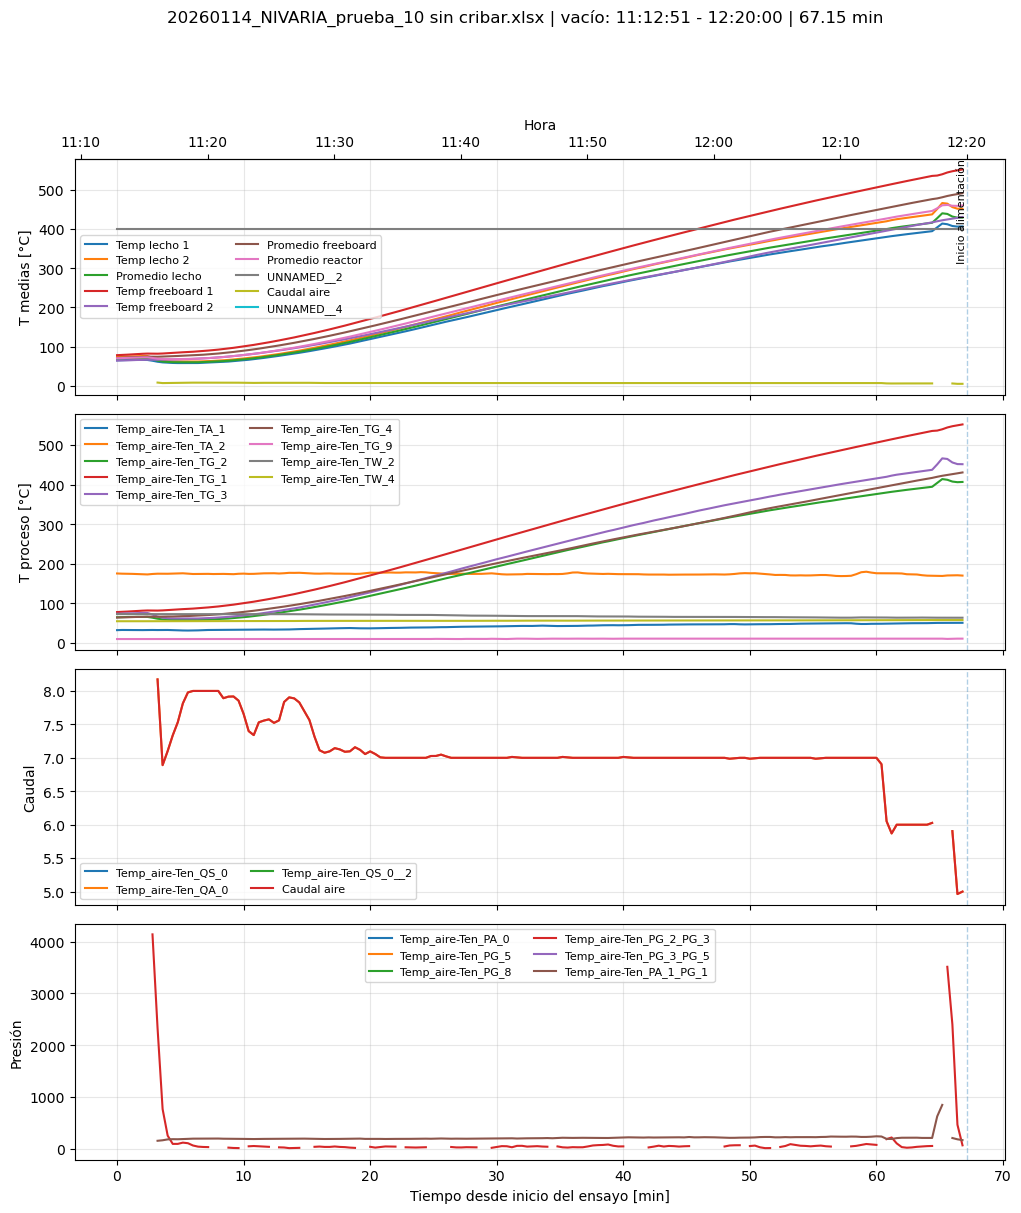

In [5]:
case = cases[1]
fig, axes = plot_empty_case_overview(case)
plt.show()

## 6. Comparar casos

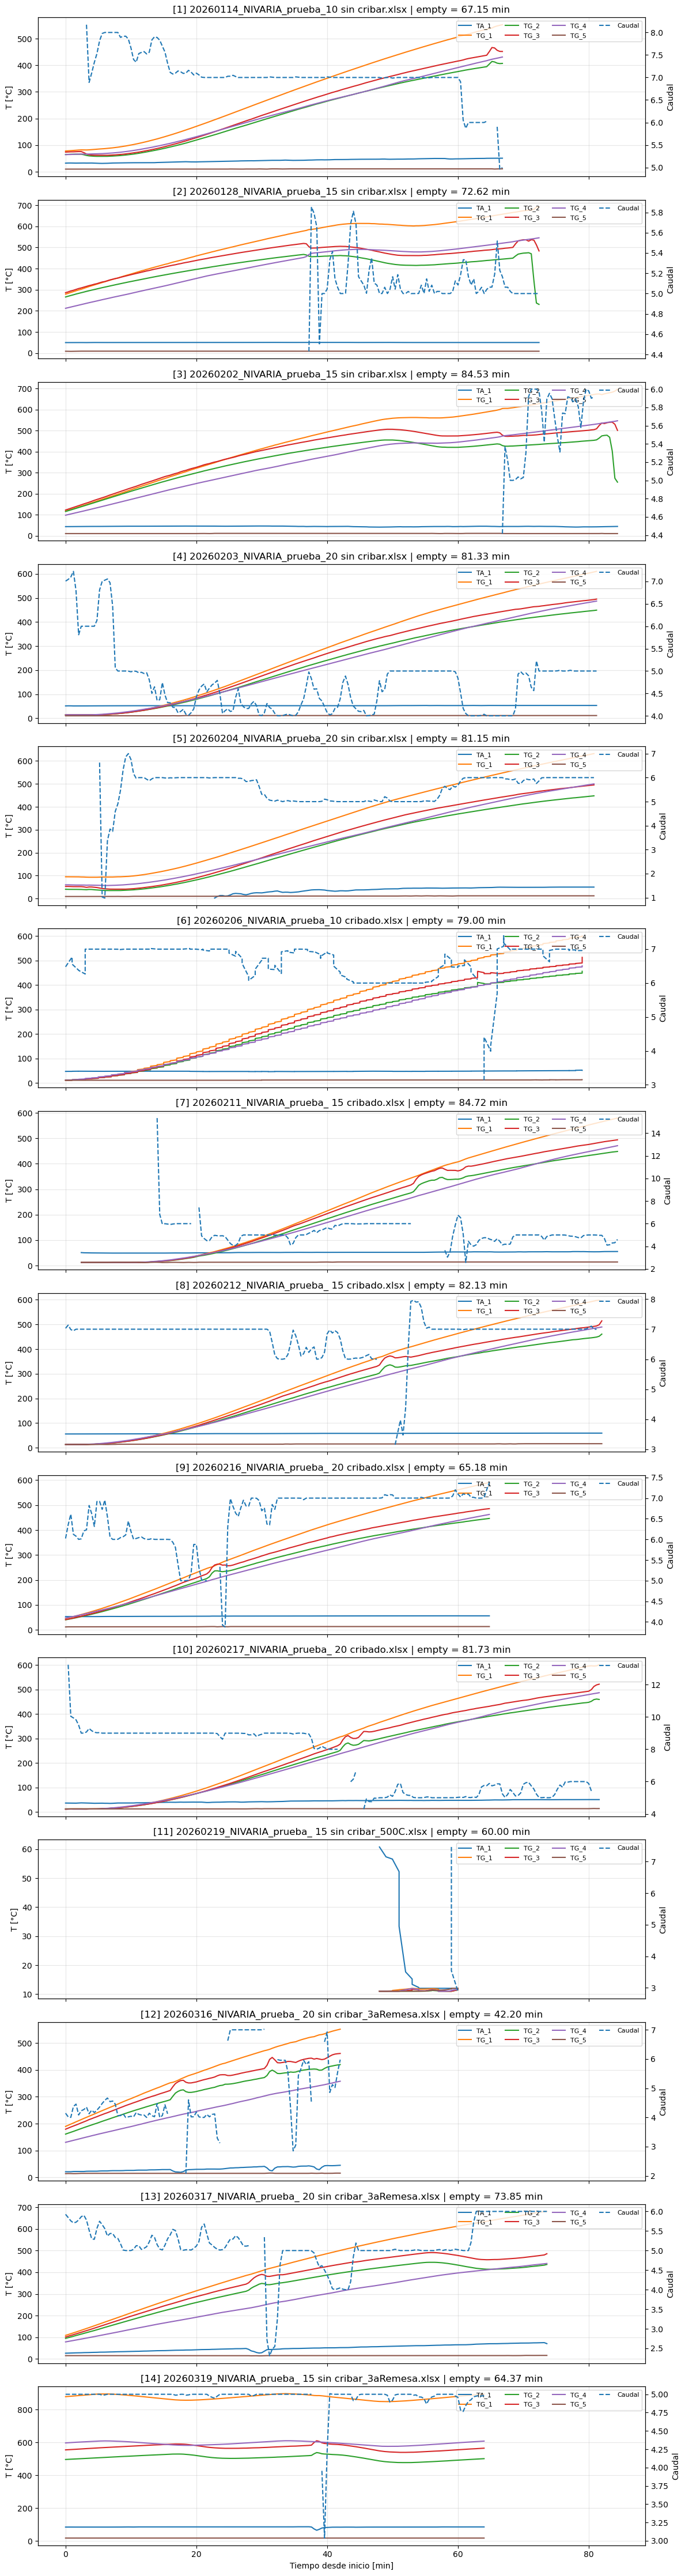

In [6]:
fig, axes = plot_selected_cases(
    cases,
    case_indices= [1, 2, 3, 4,5,6,7,8,9,10,11,12,13,14],
)

plt.show()

 ## 7.Construir solo el tramo pre-flow para los casos 2 y 3

In [7]:
cases = build_pre_flow_segments_for_cases(
    cases,
    case_indices=[2, 3],
    flow_threshold=0.0,  # o 0.01 si hay ruido
)
df_pre_flow = build_pre_flow_summary(cases)
df_pre_flow

,idx,file_name,ok_pre_flow,reason,t_start_h,t_end_h,duration_min,flow_col,flow_source
0,0,20260112_NIVARIA_prueba_10 sin cribar.xlsx,False,None,None,None,NaN,None,None
1,1,20260114_NIVARIA_prueba_10 sin cribar.xlsx,False,None,None,None,NaN,None,None
2,2,20260128_NIVARIA_prueba_15 sin cribar.xlsx,True,Tramo previo al flujo construido correctamente.,10:29:23,11:06:36,37.216667,Temp_aire-Ten_QA_0,process_empty
3,3,20260202_NIVARIA_prueba_15 sin cribar.xlsx,True,Tramo previo al flujo construido correctamente.,10:03:28,11:10:16,66.800000,Temp_aire-Ten_QA_0,process_empty
4,4,20260203_NIVARIA_prueba_20 sin cribar.xlsx,False,None,None,None,NaN,None,None
5,5,20260204_NIVARIA_prueba_20 sin cribar.xlsx,False,None,None,None,NaN,None,None
6,6,20260206_NIVARIA_prueba_10 cribado.xlsx,False,None,None,None,NaN,None,None
7,7,20260211_NIVARIA_prueba_ 15 cribado.xlsx,False,None,None,None,NaN,None,None
8,8,20260212_NIVARIA_prueba_ 15 cribado.xlsx,False,None,None,None,NaN,None,None
9,9,20260216_NIVARIA_prueba_ 20 cribado.xlsx,False,None,None,None,NaN,None,None


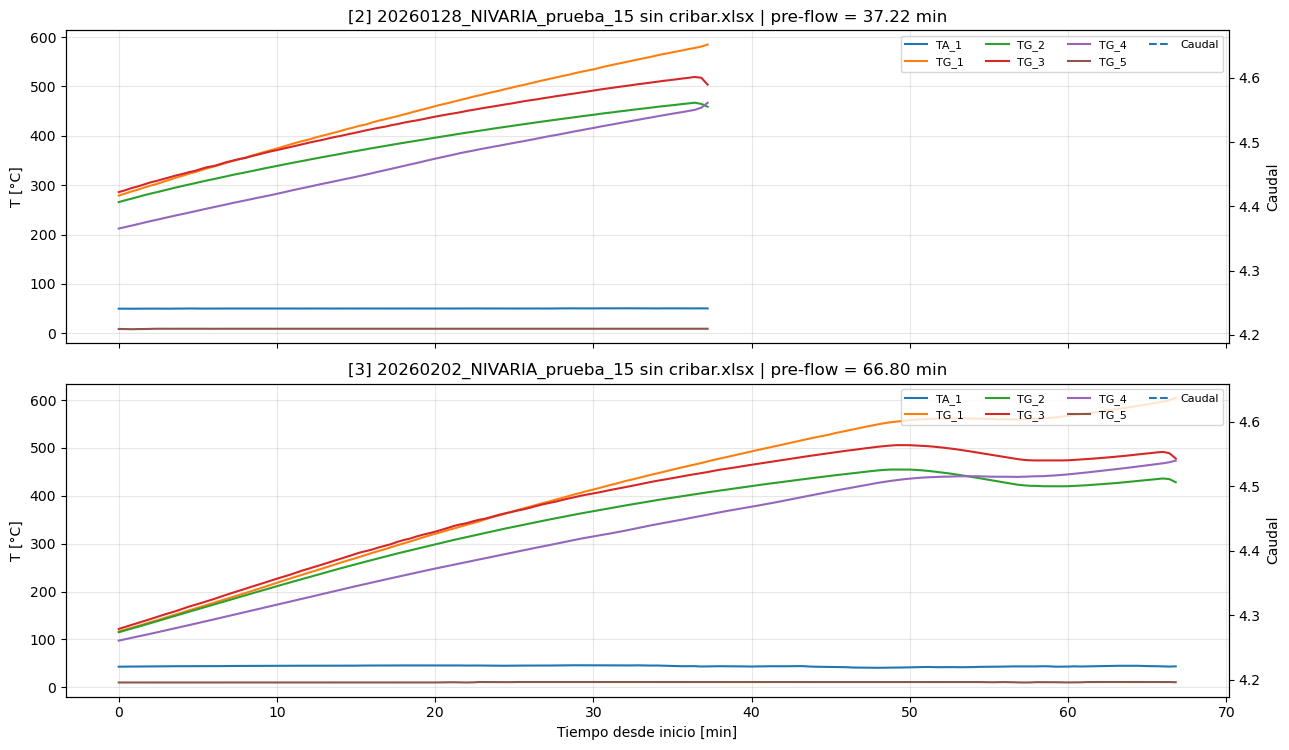

In [8]:
fig, axes = plot_selected_cases(
    cases,
    case_indices=[2, 3],
    figsize_per_row=(13, 3.8),
    data_key_process="process_pre_flow",
    data_key_avg="avgT_pre_flow",
)

plt.show()

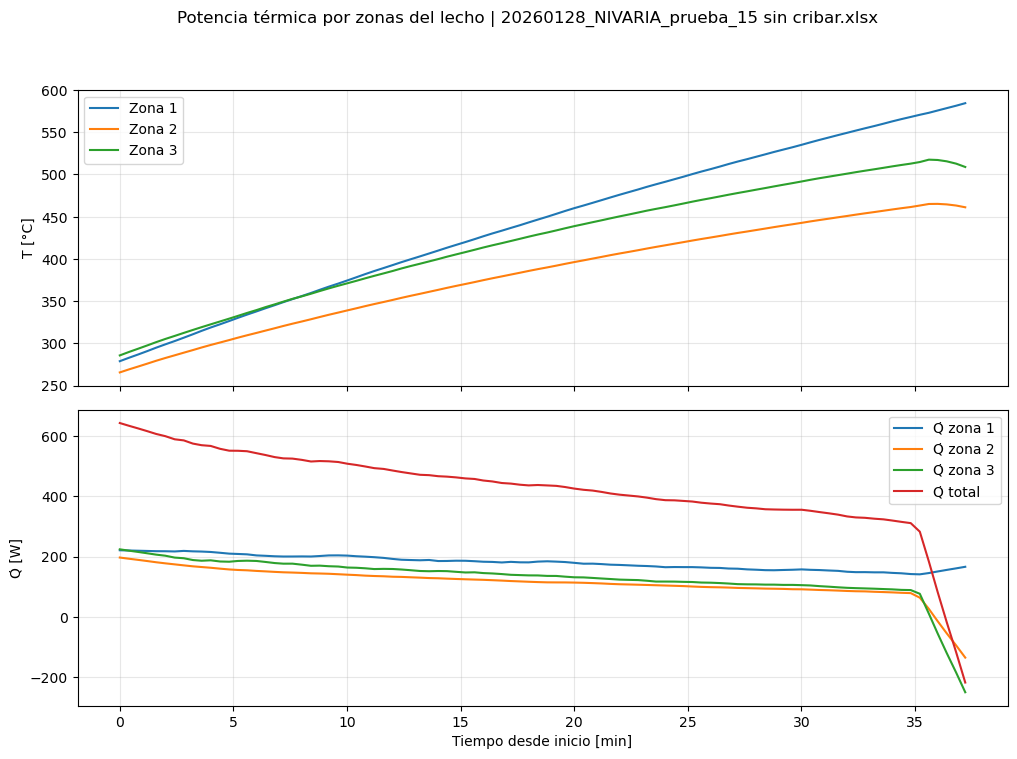

In [10]:
zone_df_2 = compute_bed_zone_power(
    cases[2],
    data_key="process_pre_flow",
    temp_cols={
        "T_z1": "Temp_aire-Ten_TG_1",
        "T_z2": "Temp_aire-Ten_TG_2",
        "T_z3": "Temp_aire-Ten_TG_3",
    },
    L_m=0.75,
    ri_m=0.04,
    ro_m=0.045,
    zone_length_m=0.75/3.0,
    rho_wall_kg_m3=7900.0,
    cp_wall_J_kg_K=500.0,
)



fig, axes = plot_bed_zone_power(
    zone_df_2,
    case_label=cases[2]["file_name"],
)
plt.show()

In [ ]:
zone_df_3 = compute_bed_zone_power(
    cases[3],
    data_key="process_pre_flow",
    temp_cols={
        "T_z1": "Temp_aire-Ten_TG_1",
        "T_z2": "Temp_aire-Ten_TG_2",
        "T_z3": "Temp_aire-Ten_TG_3",
    },
    L_m=0.75,
    ri_m=0.04,
    ro_m=0.045,
    rho_wall_kg_m3=7900.0,
    cp_wall_J_kg_K=500.0,
    zone_length_m=0.75/5.0,
)

fig, axes = plot_bed_zone_power(
    zone_df_3,
    case_label=cases[3]["file_name"],
)
plt.show()